# 05 Machine Learning Price Forecast
Trains a supervised Ridge regression / tabular ML model on lag features, rolling statistics, and external signals to forecast GPU prices.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

workspace_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(workspace_dir) not in sys.path:
    sys.path.insert(0, str(workspace_dir))

from src.io_utils import load_sample_dataset
from src.clean_prices import clean_price_observations
from src.normalize_prices import normalize_price_series
from src.feature_builder import build_gpu_features
from src.ml_forecast import MLGPUPriceForecaster

## 1. Load Data & Build Features

In [2]:
products_df = load_sample_dataset("products.csv")
listings_df = load_sample_dataset("product_listings.csv")
obs_df = load_sample_dataset("daily_price_observations.csv")
ext_df = load_sample_dataset("external_market_signals.csv")

cleaned_obs = clean_price_observations(obs_df)
norm_df = normalize_price_series(cleaned_obs, listings_df, products_df)
featured_df = build_gpu_features(norm_df, external_df=ext_df)
print(f"Feature matrix rows: {len(featured_df)}")

Feature matrix rows: 169


## 2. Train ML Forecaster

In [3]:
forecaster = MLGPUPriceForecaster(alpha=1.0)
results = forecaster.train_and_evaluate(featured_df, train_ratio=0.8)

print("=== ML Forecaster Test Metrics ===")
for metric, val in results["metrics"].items():
    print(f"{metric}: {val}")

print("=== Top Feature Coefficients ===")
coef_series = pd.Series(results["feature_coefficients"]).sort_values(key=abs, ascending=False)
display(coef_series.head(8))

=== ML Forecaster Test Metrics ===
MAE_INR: 0.0
RMSE_INR: 0.0
MAPE_Percent: 0.0
=== Top Feature Coefficients ===


total_effective_price_inr    0.2857
price_inr                    0.1429
shipping_cost_inr            0.1429
price_diff_lag_3d            0.1429
price_lag_1d                 0.1429
price_lag_7d                 0.1429
price_diff_lag_1d            0.1429
price_lag_3d                 0.1429
dtype: float64

## 3. Actual vs ML Predicted Prices Visualization

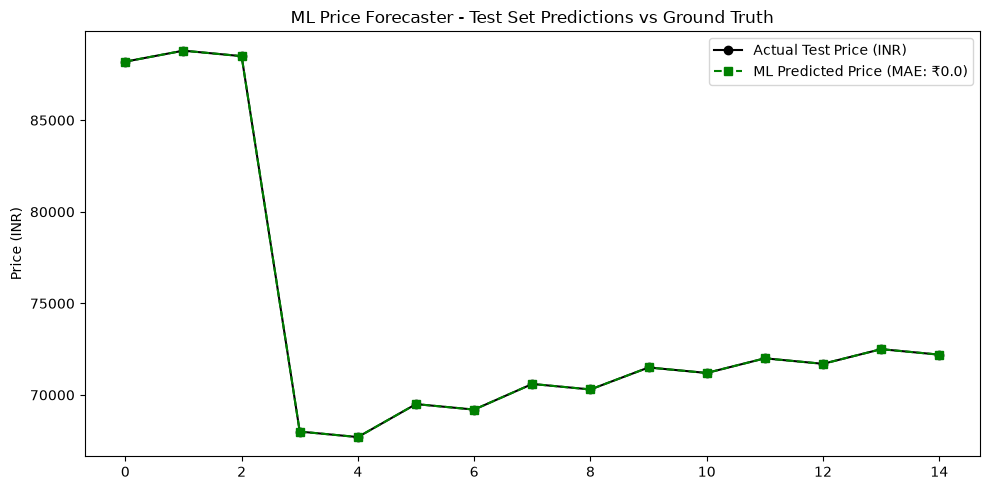

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(results["y_test"], label="Actual Test Price (INR)", color="black", marker='o')
plt.plot(results["predictions"], label=f"ML Predicted Price (MAE: ₹{results['metrics']['MAE_INR']})", color="green", linestyle="--", marker='s')
plt.title("ML Price Forecaster - Test Set Predictions vs Ground Truth")
plt.ylabel("Price (INR)")
plt.legend()
plt.tight_layout()
plt.show()